Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\Expression_TE_DESeq_Cerebellum.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\DEA_TE_DESeq_Cerebellum.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Clinical_Data_Gogliotti18.csv"
INTERGENIC_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\TE_Intergenic_With_Distances_Cerebellum.bed"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [3]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
expression_df.head()

,TE,Cer_Ctrl_1,Cer_Ctrl_2,Cer_Ctrl_3,Cer_Ctrl_4,Cer_Ctrl_5,Cer_Ctrl_6,Cer_Ctrl_7,Cer_Ctrl_8,Cer_RTT_1,Cer_RTT_3,Cer_RTT_4,Cer_RTT_5,Cer_RTT_6,Cer_RTT_7
0,TE_L2a_dup1,0,8,3,0,4,2,1,4,0,0,0,0,0,4
1,TE_AluJr_dup7,0,0,1,16,1,1,11,0,0,0,3,7,0,0
2,TE_L2a_dup16,115,238,118,144,94,195,91,271,65,73,136,83,73,104
3,TE_MIR_dup9,0,1,0,3,0,0,0,1,0,5,2,0,0,0
4,TE_L2a_dup18,2,3,0,8,0,7,0,1,5,0,6,0,4,0


DEA - Import

In [4]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,TE,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TE_MIR3_dup21111,155.619147,2.823712,0.440441,6.411102,1.444716e-10,0.000001
1,TE_MER5A1_dup6952,77.710795,2.380504,0.394136,6.039808,1.542977e-09,0.000006
2,TE_MIRb_dup90475,55.974776,2.509486,0.450833,5.566337,2.601497e-08,0.000065
3,TE_L1M4c_dup894,13946.766660,1.196564,0.217088,5.511892,3.549962e-08,0.000067
4,TE_MIR_dup2086,35.043102,2.482870,0.459534,5.403012,6.553097e-08,0.000082


Volcano plot

Classification
Non-significant    7338
Up-regulated        118
Down-regulated       89
Name: count, dtype: int64
Total tes:
40734
765
       0          1          2                    TE     4  5            6  \
0   chr1   16535843   16536004          TE_L2_dup253   367  +           L2   
1   chr1   25603229   25604932        TE_SVA_F_dup12  8573  +          SVA   
2   chr1   31175769   31177661        TE_SVA_D_dup32  8948  +          SVA   
3   chr1  103598051  103598273      TE_AluSp_dup2415  1208  -          Alu   
4   chr1  113689539  113690029       TE_MER1A_dup114  2899  -  hAT-Charlie   
..   ...        ...        ...                   ...   ... ..          ...   
65  chr9   83728742   83729392      TE_SVA_D_dup1437  5736  +          SVA   
66  chr9   85881367   85881817  TE_HERVH-int_dup5410  1926  +         ERV1   
67  chrX   57203540   57204491  TE_HERVK9-int_dup622  7421  -         ERVK   
68  chrX  135954992  135955270     TE_L1MC3_dup13224  4706  +           L1   
69  chrX

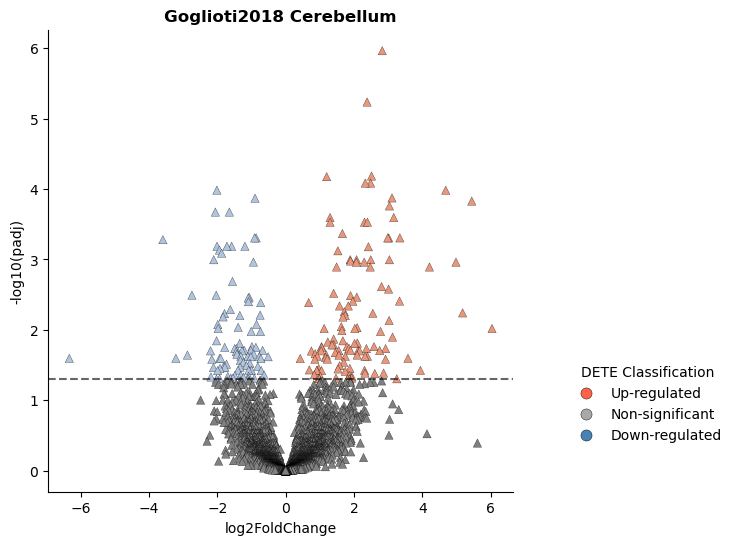

In [15]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Goglioti2018 Cerebellum', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['TE'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['TE'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['TE'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['TE'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['TE'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DETE Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    
    print('Total tes:')
    print(len(expression_df))
    
    intergenic_df = pd.read_csv(INTERGENIC_FILE, sep = '\t', header = None, comment = '#')
    intergenic_df = intergenic_df[intergenic_df.iloc[:, -1] > 4000]
    print(intergenic_df.shape[0])

    intergenic_df = intergenic_df.rename(columns = {intergenic_df.columns[3] : 'TE'})
    intergenic_dete_df = intergenic_df.merge(dea_df, on = 'TE', how = 'inner')
    print(intergenic_dete_df)
    intergenic_dete_df = intergenic_dete_df[intergenic_dete_df['Classification'] != 'Non-significant']
    print('intergenic dete')
    print(intergenic_dete_df.shape[0])

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False, marker = '^')
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [16]:
# Variables
TEs = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Sample_ID']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

pca_df.head()

   Cer_Ctrl_1  Cer_Ctrl_2  Cer_Ctrl_3  Cer_Ctrl_4  Cer_Ctrl_5  Cer_Ctrl_6  \
0    0.000000    4.537572    3.132750    0.000000    3.784654    2.719474   
1    0.000000    0.000000    1.844125    5.747435    2.068794    1.923402   
2    8.676114    9.371074    8.260503    8.893289    8.235362    9.091877   
3    0.000000    1.917644    0.000000    3.444313    0.000000    0.000000   
4    3.017285    3.222521    0.000000    4.774043    0.000000    4.361217   

   Cer_Ctrl_7  Cer_Ctrl_8  Cer_RTT_1  Cer_RTT_3  Cer_RTT_4  Cer_RTT_5  \
0    1.728110    3.091703   0.000000   0.000000   0.000000   0.000000   
1    4.724775    0.000000   0.000000   0.000000   2.770773   4.185467   
2    7.724358    8.996672   8.214873   7.755386   8.050146   7.678657   
3    0.000000    1.526697   0.000000   3.975551   2.287814   0.000000   
4    0.000000    1.526697   4.571556   0.000000   3.661005   0.000000   

   Cer_RTT_6  Cer_RTT_7  
0   0.000000   3.143224  
1   0.000000   0.000000  
2   7.296220   7.677

,Sample_Name,PC1,PC2,Condition,Sample_ID
0,Cer_Ctrl_1,-42.744110,-88.643952,Ctrl,3325-CMN-18
1,Cer_Ctrl_2,1.350635,-70.121795,Ctrl,3325-CMN-19
2,Cer_Ctrl_3,40.385736,-24.956963,Ctrl,3325-CMN-20
3,Cer_Ctrl_4,-9.603802,-77.500343,Ctrl,3325-CMN-21
4,Cer_Ctrl_5,20.492155,-56.661235,Ctrl,3325-CMN-22


PCA - Graph

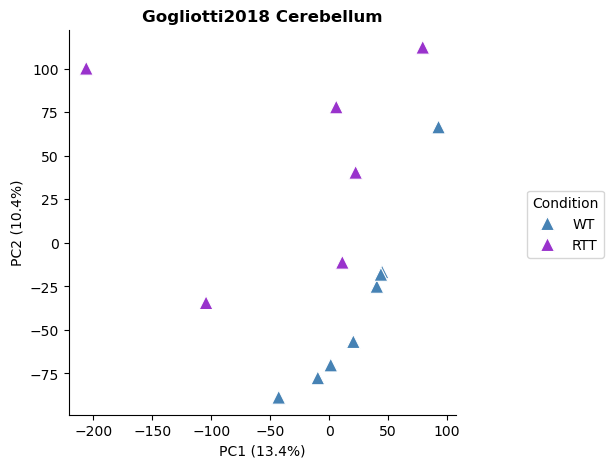

In [17]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

pca_df['Condition'] = pca_df['Condition'].replace({'Ctrl' : 'WT'})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100, marker = '^')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Gogliotti2018 Cerebellum", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [18]:
# Assemble the new table
log2cpm_df.insert(0, 'TE', TEs)
goi_df = log2cpm_df[log2cpm_df['TE'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'TE', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'Ctrl' : 'steelblue'}

sns.boxplot(data = long_df, x = 'TE', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - TEs - Cerebellum', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('TEs')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`